<a href="https://colab.research.google.com/github/HooroBoy/Pemes/blob/main/JS06/JS06_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
	# Import Required Libraries
	from pathlib import Path
	import matplotlib.image as mpimg
	import matplotlib.pyplot as plt
	import cv2
	import random
	import numpy as np
	import pandas as pd

In [5]:
	# Image directories
	train_dir = "/content/drive/MyDrive/Pemes/images/training"
	test_dir = "/content/drive/MyDrive/Pemes/images/test"

In [6]:
	def load_dataset(img_dir):
	    p = Path(img_dir)
	    dirs = p.glob('*')

	    img_list = []

	    for dir in dirs:
	        label = str(dir).split('/')[-1]
	        for file in dir.glob('*.jpg'):
	            img = mpimg.imread(file)

	            if not img is None:
	                img_list.append((img, label))

	    return img_list

In [7]:
	# Load training data
	train_img = load_dataset(train_dir)

In [8]:
	# Check the first data
	# It should be a tuple consist of arrays of image and image labels
	train_img[0]

(array([[[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],
 
        ...,
 
        [[ 52,  85, 102],
         [ 43,  76,  93],
         [ 40,  73,  88],
         ...,
         [ 13,   8,   5],
         [ 10,   5,   2],
         [  9,   4,   1]],
 
        [[ 52,  85, 102],
         [ 44,  77,  94],
         [ 41,  74,  89],
         ...,
         [ 16,  11,   8],
         [ 14,   9,   6],
         [ 12,   7,   4]],
 
        [[ 51,  84, 101],
         [ 42,  75,  92],
         [ 40,  73,  88],
         ...,
         [ 20,  15,  12],
  

In [9]:
	# Random size checking
	pick_random = np.random.randint(0, len(train_img))

	# Check img size
	print(f'Image {pick_random}')
	print(train_img[pick_random][0].shape)

Image 102
(469, 640, 3)


In [10]:
	# Function to Visualize
	def random_img_viz(img_list):
	    rand_num = np.random.randint(0, len(img_list))

	    img = img_list[rand_num][0]
	    label = img_list[rand_num][1]
	    label_str = 'day' if label == 1 else 'night'

	    plt.imshow(img)
	    print(f'Shape\t: {img.shape}')
	    print(f'Label\t: {label}')

Shape	: (700, 1280, 3)
Label	: day


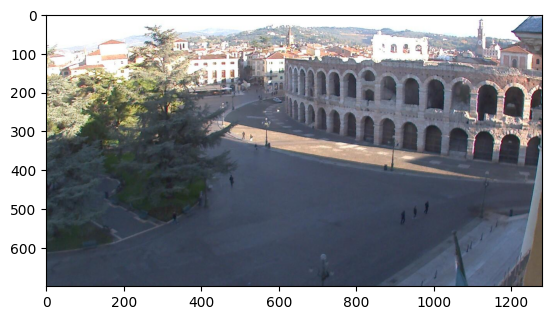

In [11]:
random_img_viz(train_img)

In [12]:
	def standarized_input(image):
	    # resize to w: 1100, h:600
	    std_img = cv2.resize(image, (1100,600))

	    return std_img

In [13]:
	def label_encoder(label):
	    # Encode the label
	    # day as 1; night as 0
	    num_val = 0

	    if(label == 'day'):
	        num_val = 1

	    return num_val

In [14]:
	def preprocess(img_list):
	    std_img_list = []

	    for item in img_list:
	        image = item[0]
	        label = item[1]

	        # Standarized the image
	        std_img = standarized_input(image)

	        # Create the label
	        img_label = label_encoder(label)

	        std_img_list.append((std_img, img_label))

	    return std_img_list

In [15]:
train_std_img_list = preprocess(train_img)

In [16]:
	# Random size checking
	pick_random = np.random.randint(0, len(train_std_img_list))

	# Check img size
	print(f'Image {pick_random}')
	print(train_std_img_list[pick_random][0].shape)

Image 110
(600, 1100, 3)


In [17]:
	# Get feature based on average brightness using HSV colorspace
	def avg_brightness(image):
	    # Convert image to HSV
	    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

	    # Calculate the avg of brightness
	    sum_brightness = np.sum(img_hsv[:,:,2]) # take the 3rb value which is the V channel
	    area = image.shape[0] * image.shape[1]
	    avg = sum_brightness / area

	    return avg

Image 116
Avg Brighness: 112.8596


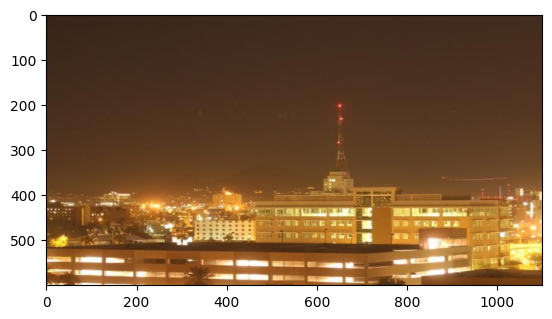

In [18]:
	# Check on random image
	rand_img = np.random.randint(0, len(train_std_img_list))

	feature_img = train_std_img_list[rand_img][0]

	avg_img = avg_brightness(feature_img)

	print(f'Image {rand_img}')
	print(f'Avg Brighness: {avg_img:.4f}')
	plt.imshow(feature_img)

In [19]:
	def predict_label(img, threshold):
	    # Computer average brightness
	    avg = avg_brightness(img)
	    pred = 0

	    # Predict the label based on user defined threshold
	    if avg > threshold:
	        pred = 1

	    return pred

Image 118
Actual label: 0
Predicted label: 0


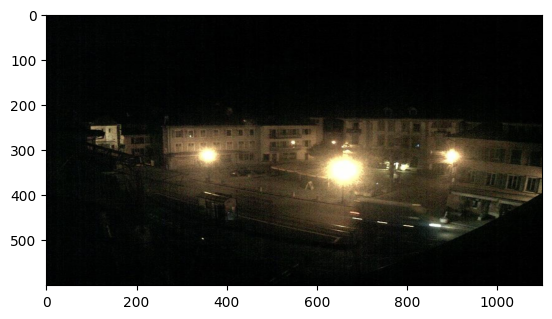

In [20]:
	# Test the classifier on train data
	rand_img = np.random.randint(0, len(train_std_img_list))

	pred = predict_label(train_std_img_list[rand_img][0], threshold=120)

	# Evaluate
	print(f'Image {rand_img}')
	print(f'Actual label: {train_std_img_list[rand_img][1]}')
	print(f'Predicted label: {pred}')
	plt.imshow(train_std_img_list[rand_img][0])

In [21]:
	def evaluate(img_list, threshold):
	    miss_labels = []

	    for file in img_list:
	        # Get the ground truth / correct label
	        img = file[0]
	        label = file[1]

	        # Get prediction
	        pred_label = predict_label(img, threshold)

	        # Compare ground truth and pred
	        if pred_label != label:
	            miss_labels.append((img, pred_label, label))

	    total_img = len(img_list)
	    corr_pred = total_img - len(miss_labels)
	    accuracy = corr_pred / total_img

	    print(f'Accuracy: {accuracy:.4f}')

In [22]:
	# Evaluate on train data
	evaluate(train_std_img_list, threshold=120)

Accuracy: 0.8417


In [23]:
	# Evaluate on test data

	# Load test data
	test_img = load_dataset(test_dir)

	# Preprocess
	test_std_img_list = preprocess(test_img)

	# Predict
	evaluate(test_std_img_list, threshold=120)

Accuracy: 0.8688


In [24]:
	# Create function to extract feature for every images and stored in tabular data
	# Stored in Pandas dataframe
	def extract_avg_bright_feature(img_list):
	    avg_list = []
	    labels = []

	    for img in img_list:
	        img_avg = avg_brightness(img[0]) # Get the avg brightness from image
	        img_label = img[1] # Get the image label

	        avg_list.append(img_avg)
	        labels.append(img_label)

	    # Stack data in columcular way
	    data = np.column_stack((avg_list, labels))
	    # Create a Pandas dataframe
	    df = pd.DataFrame(data, columns=['AVG_BRIGHT', 'LABELS'])

	    return df

In [25]:
	# Extract feature on train data
	train_avg_img = extract_avg_bright_feature(train_std_img_list)
	print(f'Shape: {train_avg_img.shape}')
	train_avg_img.head()

Shape: (240, 2)


,AVG_BRIGHT,LABELS
0,91.782092,0.0
1,92.701620,0.0
2,39.105368,0.0
3,89.905798,0.0
4,24.501535,0.0


In [26]:
	# Do the same thing on test data
	test_avg_img = extract_avg_bright_feature(test_std_img_list)
	print(f'Shape: {test_avg_img.shape}')
	test_avg_img.head()

Shape: (160, 2)


,AVG_BRIGHT,LABELS
0,37.642245,0.0
1,86.790155,0.0
2,13.228938,0.0
3,89.160545,0.0
4,34.766211,0.0


In [27]:
	# import requied library
	from sklearn.svm import SVC

	# Split data and label
	X_train = train_avg_img.iloc[:,0].values.reshape(-1,1)
	y_train = train_avg_img.iloc[:,1]
	X_test = test_avg_img.iloc[:,0].values.reshape(-1,1)
	y_test = test_avg_img.iloc[:,1]

	model = SVC()
	model.fit(X_train, y_train)

SVC()

In [28]:
	from sklearn.metrics import accuracy_score

	# Make a prediction on train data
	y_train_pred = model.predict(X_train)

	# Get the accuracy on train data
	acc_train = accuracy_score(y_train, y_train_pred)

	# Make a prediction on test data
	y_test_pred = model.predict(X_test)

	# Get the accuracy on test data
	acc_test = accuracy_score(y_test, y_test_pred)

	# Print Eval Result
	print(f'Accuracy on train: {acc_train}')
	print(f'Accuracy on test: {acc_test}')

Accuracy on train: 0.8583333333333333
Accuracy on test: 0.9
